In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_excel('data/dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx')
data.drop(index = 56, inplace = True) #удалил строку с общим итогом чтобы в describe не поехали цифры при анализе датасета

In [3]:
data.head(3)

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46


In [4]:
data.groupby('Неделя').describe()

Установки                                                            \
             count        mean        std    min    25%    50%    75%    max   
Неделя                                                                         
Неделя 1       7.0  208.285714  12.605743  181.0  209.0  212.0  214.5  218.0   
Неделя 2       7.0  202.142857  12.759684  189.0  190.0  205.0  210.5  220.0   
Неделя 3       7.0  204.714286  12.776466  184.0  197.0  207.0  214.0  220.0   
Неделя 4       7.0  201.000000  14.525839  181.0  191.5  197.0  213.0  220.0   
Неделя 5       7.0  204.714286  12.161610  189.0  194.5  209.0  213.0  220.0   
Неделя 6       7.0  193.857143   6.466028  186.0  189.5  191.0  199.5  202.0   
Неделя 7       7.0  218.000000  14.071247  201.0  206.5  217.0  230.0  235.0   
Неделя 8       7.0  218.285714  15.660080  199.0  207.0  212.0  232.5  238.0   

         Регистрации              ... Забронировали       Первая поездка  \
               count        mean  ...           75%   max          count   
Неделя                            ...                                      
Неделя 1         7.0  136.142857  ...          67.0  72.0            7.0   
Неделя 2         7.0  133.285714  ...          64.0  74.0            7.0   
Неделя 3         7.0  139.000000  ...          67.0  71.0            7.0   
Неделя 4         7.0  136.571429  ...          61.5  64.0            7.0   
Неделя 5         7.0  136.571429  ...          64.5  82.0            7.0   
Неделя 6         7.0  131.714286  ...          61.5  62.0            7.0   
Неделя 7         7.0  145.857143  ...          50.5  55.0            7.0   
Неделя 8         7.0  147.285714  ...          51.0  53.0            7.0   

                                                             
               mean       std   min   25%   50%   75%   max  
Неделя                                                       
Неделя 1  53.428571  5.883795  46.0  49.5  53.0  57.0  62.0  
Неделя 2  52.571429  8.734169  41.0  48.0  52.0  56.0  67.0  
Неделя 3  54.142857  5.520524  48.0  50.5  53.0  56.5  64.0  
Неделя 4  52.000000  3.214550  46.0  51.0  52.0  54.5  55.0  
Неделя 5  54.714286  6.600866  50.0  51.0  53.0  54.5  69.0  
Неделя 6  53.285714  3.302236  49.0  50.5  55.0  55.0  58.0  
Неделя 7  40.428571  3.598942  36.0  37.5  41.0  42.5  46.0  
Неделя 8  42.714286  3.251373  39.0  40.5  42.0  44.5  48.0  

[8 rows x 48 columns]

In [5]:
data_week = data.groupby("Неделя")[[
    "Установки",
    "Регистрации",
    "Открыли поиск",
    "Просмотрели авто",
    "Забронировали",
    "Первая поездка"
]].sum()

data_week["% регистраций"] = data_week['Регистрации'] / data_week['Установки']
data_week["% поиска"] = data_week["Открыли поиск"] / data_week["Регистрации"]
data_week["% просмотра"] = data_week["Просмотрели авто"] / data_week["Открыли поиск"]
data_week["% брони"] = data_week["Забронировали"] / data_week["Просмотрели авто"]
data_week["% первых поездок"] = data_week["Первая поездка"] / data_week["Забронировали"]
data_week["конверсия"] = data_week["Первая поездка"] / data_week["Установки"]

data_week

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,% регистраций,% поиска,% просмотра,% брони,% первых поездок,конверсия
Неделя,,,,,,,,,,,,
Неделя 1,1458,953,689,547,430,374,0.653635,0.722980,0.793904,0.786106,0.869767,0.256516
Неделя 2,1415,933,661,522,411,368,0.659364,0.708467,0.789713,0.787356,0.895377,0.260071
Неделя 3,1433,973,721,581,440,379,0.678995,0.741007,0.805825,0.757315,0.861364,0.264480
Неделя 4,1407,956,688,549,415,364,0.679460,0.719665,0.797965,0.755920,0.877108,0.258706
Неделя 5,1433,956,696,556,440,383,0.667132,0.728033,0.798851,0.791367,0.870455,0.267271
Неделя 6,1357,922,653,516,411,373,0.679440,0.708243,0.790199,0.796512,0.907543,0.274871
Неделя 7,1526,1021,504,424,336,283,0.669069,0.493634,0.841270,0.792453,0.842262,0.185452
Неделя 8,1528,1031,519,421,335,299,0.674738,0.503395,0.811175,0.795724,0.892537,0.195681


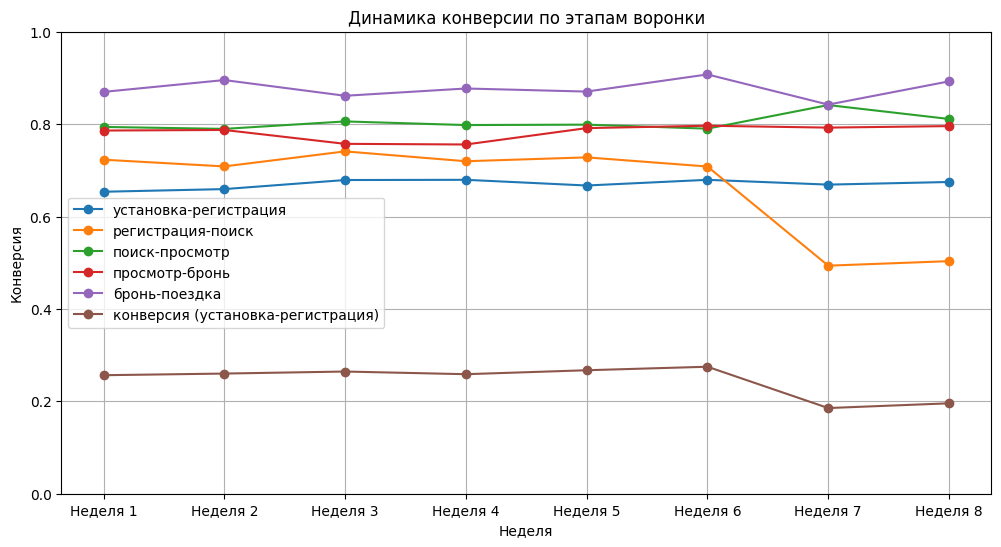

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(data_week.index, data_week["% регистраций"], marker="o", label="установка-регистрация")
plt.plot(data_week.index, data_week["% поиска"], marker="o", label="регистрация-поиск")
plt.plot(data_week.index, data_week["% просмотра"], marker="o", label="поиск-просмотр")
plt.plot(data_week.index, data_week["% брони"], marker="o", label="просмотр-бронь")
plt.plot(data_week.index, data_week["% первых поездок"], marker="o", label="бронь-поездка")
plt.plot(data_week.index, data_week["конверсия"], marker="o", label="конверсия (установка-регистрация)")

plt.title("Динамика конверсии по этапам воронки")
plt.xlabel("Неделя")
plt.ylabel("Конверсия")
plt.ylim(0, 1)  # чтобы было в процентах 0–100%
plt.grid(True)
plt.legend()
plt.show()

Падение конверсии заметно на 7 и 8 неделе. Больше всего потерь на этапе воронки регистрация-поиск. Т.к. новых крупных обновлений не было, кроме изменений в поиске авто, то можно предположить, что проблема связана с изменением поиска авто. 

В дальнейшем посмотрел бы на изменения UI/UX, возможно удлинился/усложнился путь юзера. Возможно поможет выгрузка отчета по кликам юзеров или проведение A/B тестов с откатом версии до прошлой на части юзеров.